# Improve Stock Model Accuracy

This notebook is designed for Google Colab. It compares the original Logistic Regression baseline with an improved Extra Trees model using the same four features expected by the FastAPI app: `Return`, `MA_5`, `MA_10`, and `Volatility`.

Use a time-based split for evaluation so the model is tested on later dates, which better matches forecasting behavior.

## 1. Install Dependencies

If you opened this notebook from the repo in Colab, run the first cell from the project root. If dependencies are already installed, this cell is still safe to run.

In [1]:
!pip install -q pandas scikit-learn joblib matplotlib

## 2. Load Processed Data

The notebook first looks for `data/processed/AAPL_features.csv`. If the file is not available in Colab, upload it when prompted.

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

try:
    from google.colab import files
except ImportError:
    files = None

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_data_path(filename="AAPL_features.csv"):
    candidates = [
        Path.cwd() / "data" / "processed" / filename,
        Path.cwd().parent / "data" / "processed" / filename,
        Path.cwd() / filename,
    ]

    for parent in Path.cwd().parents:
        candidates.append(parent / "data" / "processed" / filename)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


DATA_PATH = find_data_path()

if DATA_PATH is None:
    if files is None:
        raise FileNotFoundError(
            "AAPL_features.csv was not found. Start Jupyter from the project root, "
            "or place the file at data/processed/AAPL_features.csv."
        )

    print("Upload AAPL_features.csv from data/processed/ in your repo.")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = Path(uploaded_name)

print(f"Using data file: {DATA_PATH}")
df = pd.read_csv(DATA_PATH).sort_values("Date").reset_index(drop=True)
df.head()

Using data file: /Users/nishanthshastry/Masters Main Folder/Masters Quarter 6/SE 489 ML Engineering for Production/mlops-stock-project/data/processed/AAPL_features.csv


,Date,Close,High,Low,Open,Volume,Return,MA_5,MA_10,Volatility,Target
0,2024-06-14,210.665115,213.322092,209.485333,212.013436,70122700,-0.008168,206.227560,199.837912,8.684611,1
1,2024-06-17,214.809219,217.069637,210.893145,211.537557,93728300,0.019672,210.897113,202.082469,3.473949,0
2,2024-06-18,212.449661,216.752401,211.170746,215.721324,79943300,-0.010984,212.312851,204.059343,1.590903,0
3,2024-06-20,207.879257,212.400109,207.056399,212.092758,86172500,-0.021513,211.640671,205.428484,2.567627,0
4,2024-06-21,205.708069,210.070275,205.331327,208.583157,241805100,-0.010444,210.302264,206.718311,3.606703,1


In [3]:
print(df.shape)
print(df["Target"].value_counts(normalize=True))
df[["Date", "Return", "MA_5", "MA_10", "Volatility", "Target"]].tail()

(492, 11)
Target
1    0.54878
0    0.45122
Name: proportion, dtype: float64


,Date,Return,MA_5,MA_10,Volatility,Target
487,2026-05-27,0.008173,307.047998,302.935999,3.409361,1
488,2026-05-28,0.005340,309.100000,304.300000,2.839638,0
489,2026-05-29,-0.001440,310.514001,305.685001,1.879268,0
490,2026-06-01,-0.018426,310.012000,306.292999,2.630142,1
491,2026-06-02,0.019178,310.782904,307.727451,2.578263,0


## 3. Time-Based Train/Test Split

In [4]:
FEATURES = ["Return", "MA_5", "MA_10", "Volatility"]
TARGET = "Target"

split_index = int(len(df) * 0.8)

X_train = df.loc[: split_index - 1, FEATURES]
X_test = df.loc[split_index:, FEATURES]
y_train = df.loc[: split_index - 1, TARGET]
y_test = df.loc[split_index:, TARGET]

print("Train dates:", df.loc[0, "Date"], "to", df.loc[split_index - 1, "Date"])
print("Test dates:", df.loc[split_index, "Date"], "to", df.loc[len(df) - 1, "Date"])
print("Train rows:", len(X_train), "Test rows:", len(X_test))

Train dates: 2024-06-14 to 2026-01-08
Test dates: 2026-01-09 to 2026-06-02
Train rows: 393 Test rows: 99


## 4. Compare Baseline and Improved Model

In [5]:
models = {
    "baseline_logistic_regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42)),
        ]
    ),
    "improved_extra_trees": ExtraTreesClassifier(
        n_estimators=400,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append({"model": name, "accuracy": accuracy})
    print(f"\n{name}: accuracy={accuracy:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

pd.DataFrame(results).sort_values("accuracy", ascending=False)


baseline_logistic_regression: accuracy=0.4747
              precision    recall  f1-score   support

           0       0.45      0.69      0.54        45
           1       0.53      0.30      0.38        54

    accuracy                           0.47        99
   macro avg       0.49      0.49      0.46        99
weighted avg       0.50      0.47      0.46        99


improved_extra_trees: accuracy=0.5657
              precision    recall  f1-score   support

           0       0.52      0.58      0.55        45
           1       0.61      0.56      0.58        54

    accuracy                           0.57        99
   macro avg       0.57      0.57      0.56        99
weighted avg       0.57      0.57      0.57        99



,model,accuracy
1,improved_extra_trees,0.565657
0,baseline_logistic_regression,0.474747


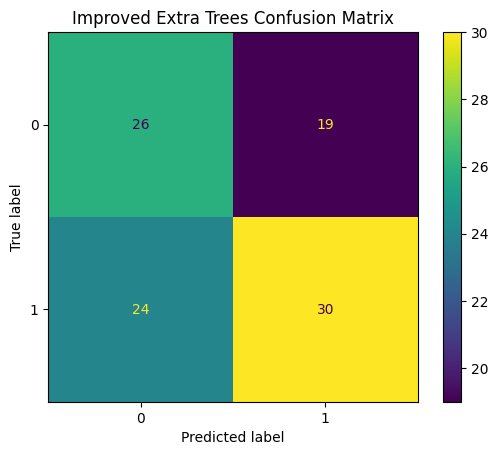

In [6]:
best_model = models["improved_extra_trees"]
best_predictions = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, best_predictions)
plt.title("Improved Extra Trees Confusion Matrix")
plt.show()

## 5. Save the Improved Model

This saves a model artifact compatible with the current FastAPI `/predict` endpoint because it uses the same four input features.

In [14]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "model_v1.pkl"

joblib.dump(best_model, MODEL_PATH)
print(f"Saved model to {MODEL_PATH}")

Saved model to models/model_v1.pkl
